<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/v-kernel/blob/main/notebooks/diffusion_checkpoint_rollback.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

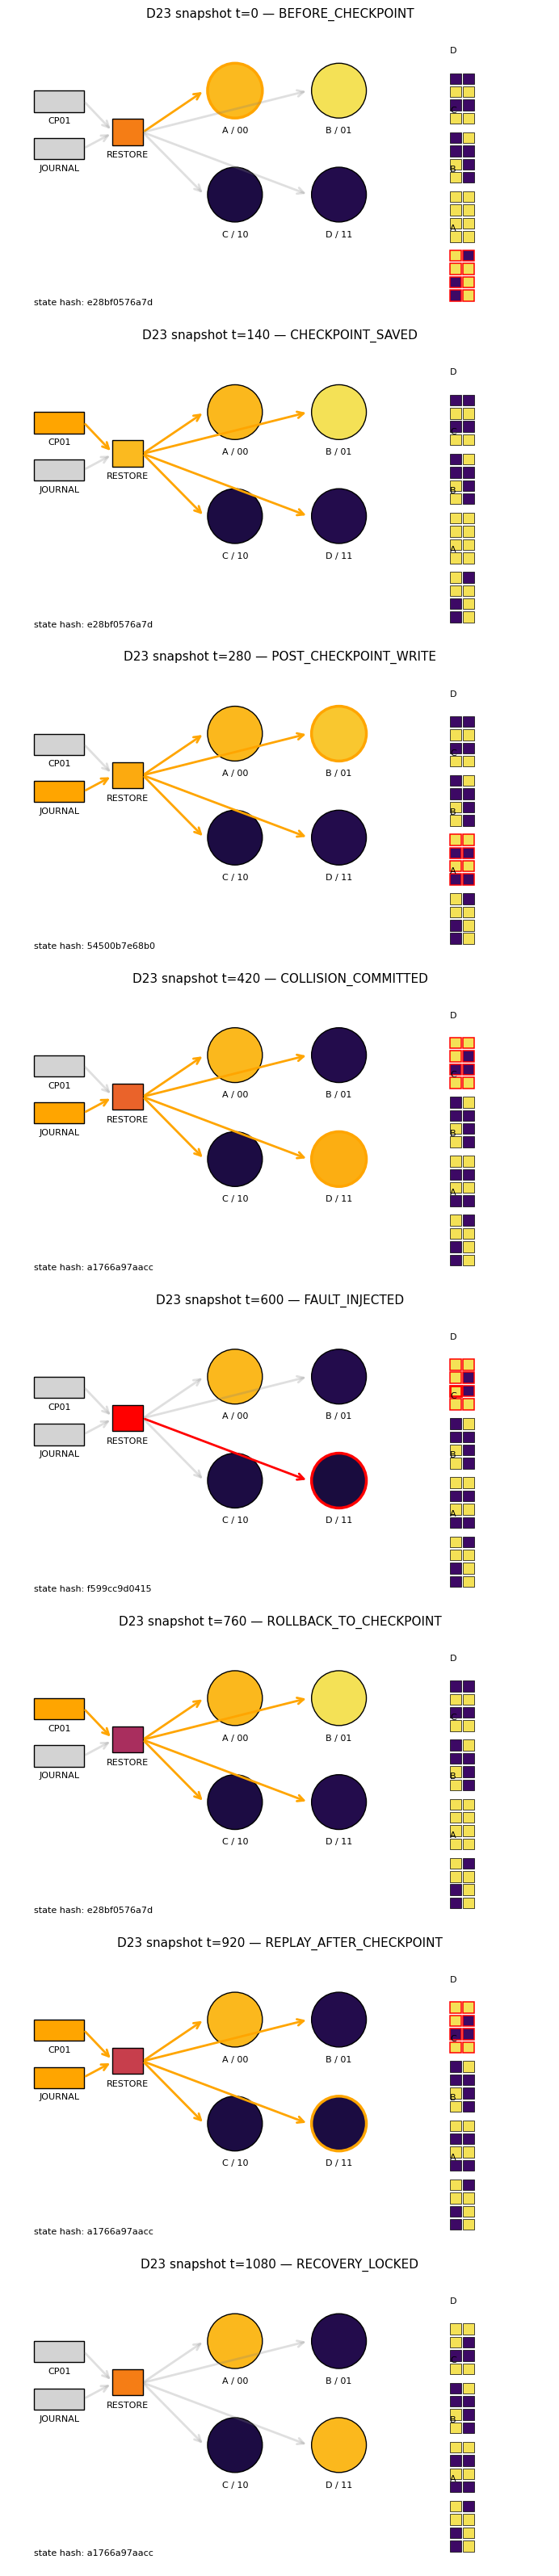

STATE: CHECKPOINT_ROLLBACK_LOCKED
checkpoint id:          CP01
checkpoint after tx:    TX01
transactions total:     4
post-checkpoint replay: 2
fault cell:             MEM_CELL_D
fault slot:             4
fault detected:         True
rollback accuracy:      1.0
replay recovery acc:    1.0
journal integrity:      1.0
checkpoint hash:        e28bf0576a7d
clean final hash:       a1766a97aacc
corrupted hash:         f599cc9d0415
recovered hash:         a1766a97aacc
final log hash:         53489c9790bc

Address decode table:


,STATE,TX_ID,SOURCE,ADDRESS_BIT_INDEX,INPUT_ADDRESS_BIT,RECEIVED_MEAN,DECODED_ADDRESS_BIT,MATCH
0,D23_CHECKPOINT_ROLLBACK,TX00,A,0,0,0.243,0,1
1,D23_CHECKPOINT_ROLLBACK,TX00,A,1,0,0.221,0,1
2,D23_CHECKPOINT_ROLLBACK,TX01,B,0,1,0.713,1,1
3,D23_CHECKPOINT_ROLLBACK,TX01,B,1,0,0.253,0,1
4,D23_CHECKPOINT_ROLLBACK,TX02,B,0,0,0.245,0,1
5,D23_CHECKPOINT_ROLLBACK,TX02,B,1,1,0.703,1,1
6,D23_CHECKPOINT_ROLLBACK,TX03,A,0,1,0.727,1,1
7,D23_CHECKPOINT_ROLLBACK,TX03,A,1,1,0.700,1,1
8,D23_CHECKPOINT_ROLLBACK,TX03,B,0,1,0.694,1,1
9,D23_CHECKPOINT_ROLLBACK,TX03,B,1,1,0.802,1,1



Transaction log:


,STATE,TX_ID,OP,WRITER,ADDR_A,ADDR_B,SELECTED_CELL,WINNER,BEFORE_SEQUENCE,PAYLOAD_WRITTEN,AFTER_SEQUENCE,RESULT,PREV_HASH,TX_HASH
0,D23_CHECKPOINT_ROLLBACK,TX00,WRITE,A,00,,MEM_CELL_A,A,00000000,10110101,10110101,COMMITTED,GENESIS0000,a625b484d23a
1,D23_CHECKPOINT_ROLLBACK,TX01,WRITE,B,,10,MEM_CELL_C,B,01001010,01001010,01001010,COMMITTED,a625b484d23a,bea83af3a101
2,D23_CHECKPOINT_ROLLBACK,TX02,WRITE,B,,01,MEM_CELL_B,B,11111111,11001100,11001100,COMMITTED,bea83af3a101,f0933f15d703
3,D23_CHECKPOINT_ROLLBACK,TX03,COLLISION_WRITE,A+B,11,11,MEM_CELL_D,A,00110011,11100011,11100011,COLLISION_ARBITRATED,f0933f15d703,53489c9790bc



Checkpoint table:


...

,STATE,CELL,CLEAN_FINAL_SEQUENCE,CORRUPTED_SEQUENCE,AFTER_ROLLBACK_SEQUENCE,AFTER_REPLAY_SEQUENCE,CORRUPTION_MATCH_CLEAN,ROLLBACK_MATCH_CHECKPOINT,RECOVERY_MATCH_CLEAN
0,D23_CHECKPOINT_ROLLBACK,MEM_CELL_A,10110101,10110101,10110101,10110101,1,1,1
1,D23_CHECKPOINT_ROLLBACK,MEM_CELL_B,11001100,11001100,11111111,11001100,1,1,1
2,D23_CHECKPOINT_ROLLBACK,MEM_CELL_C,01001010,01001010,01001010,01001010,1,1,1
3,D23_CHECKPOINT_ROLLBACK,MEM_CELL_D,11100011,11101011,00110011,11100011,0,1,1



Hash-chain integrity table:


,STATE,TX_ID,EXPECTED_PREV_HASH,LOG_PREV_HASH,EXPECTED_TX_HASH,LOG_TX_HASH,HASH_OK
0,D23_CHECKPOINT_ROLLBACK,TX00,GENESIS0000,GENESIS0000,a625b484d23a,a625b484d23a,1
1,D23_CHECKPOINT_ROLLBACK,TX01,a625b484d23a,a625b484d23a,bea83af3a101,bea83af3a101,1
2,D23_CHECKPOINT_ROLLBACK,TX02,bea83af3a101,bea83af3a101,f0933f15d703,f0933f15d703,1
3,D23_CHECKPOINT_ROLLBACK,TX03,f0933f15d703,f0933f15d703,53489c9790bc,53489c9790bc,1



Summary:


,STATE,RESULT,CHECKPOINT_ID,CHECKPOINT_AFTER_TX,TRANSACTIONS_TOTAL,POST_CHECKPOINT_REPLAYED,FAULT_CELL,FAULT_SLOT,FAULT_DETECTED,ROLLBACK_ACCURACY,REPLAY_RECOVERY_ACCURACY,JOURNAL_INTEGRITY,CHECKPOINT_HASH,CLEAN_FINAL_HASH,CORRUPTED_HASH,RECOVERED_HASH,FINAL_LOG_HASH
0,D23_CHECKPOINT_ROLLBACK,CHECKPOINT_ROLLBACK_LOCKED,CP01,TX01,4,2,MEM_CELL_D,4,1,1.0,1.0,1.0,e28bf0576a7d,a1766a97aacc,f599cc9d0415,a1766a97aacc,53489c9790bc


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hashlib
from copy import deepcopy
from matplotlib.patches import Circle, Rectangle, FancyArrowPatch

# ============================================================
# D23_CHECKPOINT_ROLLBACK
# Field memory checkpoint, rollback, and journal replay recovery
#
# Goal:
# routed memory transactions
# -> checkpoint saved
# -> post-checkpoint writes
# -> injected memory fault
# -> detect mismatch
# -> rollback to checkpoint
# -> replay committed journal after checkpoint
# -> recover clean memory state
# ============================================================

np.random.seed(23)

STATE = "D23_CHECKPOINT_ROLLBACK"

decode_threshold = 0.50
checkpoint_id = "CP01"

address_map = {
    "00": "MEM_CELL_A",
    "01": "MEM_CELL_B",
    "10": "MEM_CELL_C",
    "11": "MEM_CELL_D",
}

memory_initial = {
    "MEM_CELL_A": "00000000",
    "MEM_CELL_B": "11111111",
    "MEM_CELL_C": "01001010",
    "MEM_CELL_D": "00110011",
}

tx_plan = [
    {
        "TX_ID": "TX00",
        "OP": "WRITE",
        "SOURCE": "A",
        "ADDR_A": "00",
        "PAYLOAD_A": "10110101",
        "ADDR_B": "",
        "PAYLOAD_B": "",
    },
    {
        "TX_ID": "TX01",
        "OP": "WRITE",
        "SOURCE": "B",
        "ADDR_A": "",
        "PAYLOAD_A": "",
        "ADDR_B": "10",
        "PAYLOAD_B": "01001010",
    },
    {
        "TX_ID": "TX02",
        "OP": "WRITE",
        "SOURCE": "B",
        "ADDR_A": "",
        "PAYLOAD_A": "",
        "ADDR_B": "01",
        "PAYLOAD_B": "11001100",
    },
    {
        "TX_ID": "TX03",
        "OP": "COLLISION_WRITE",
        "SOURCE": "A+B",
        "ADDR_A": "11",
        "PAYLOAD_A": "11100011",
        "ADDR_B": "11",
        "PAYLOAD_B": "00011100",
    },
]

checkpoint_after_tx = "TX01"


def seq_to_bits(seq):
    return [int(x) for x in seq]


def bits_to_string(bits):
    return "".join(str(int(x)) for x in bits)


def accuracy(a, b):
    a_bits = np.array(seq_to_bits(a))
    b_bits = np.array(seq_to_bits(b))
    return float(np.mean(a_bits == b_bits))


def memory_accuracy(mem_a, mem_b):
    scores = []
    for cell in mem_a:
        scores.append(accuracy(mem_a[cell], mem_b[cell]))
    return float(np.mean(scores))


def short_hash(text, n=12):
    return hashlib.sha256(text.encode("utf-8")).hexdigest()[:n]


def memory_hash(memory_state):
    canonical = "|".join(f"{cell}:{memory_state[cell]}" for cell in sorted(memory_state))
    return short_hash(canonical)


def tx_hash(prev_hash, tx_id, op, writer, addr_a, addr_b, selected_cell, winner, before, payload, after, result):
    canonical = "|".join([
        prev_hash,
        tx_id,
        op,
        writer,
        addr_a,
        addr_b,
        selected_cell,
        winner,
        before,
        payload,
        after,
        result,
    ])
    return short_hash(canonical)


def decode_address_bits(address_bits, tx_id, source):
    received = []
    rows = []

    for i, bit in enumerate(address_bits):
        if bit == "1":
            value = 0.74 + np.random.normal(0, 0.035)
        else:
            value = 0.22 + np.random.normal(0, 0.035)

        value = float(np.clip(value, 0.0, 1.0))
        decoded = 1 if value >= decode_threshold else 0

        received.append(decoded)

        rows.append({
            "STATE": STATE,
            "TX_ID": tx_id,
            "SOURCE": source,
            "ADDRESS_BIT_INDEX": i,
            "INPUT_ADDRESS_BIT": int(bit),
            "RECEIVED_MEAN": round(value, 3),
            "DECODED_ADDRESS_BIT": decoded,
            "MATCH": int(decoded == int(bit)),
        })

    return bits_to_string(received), rows


def apply_transaction(memory_state, tx, prev_hash):
    op = tx["OP"]
    tx_id = tx["TX_ID"]

    address_rows = []

    if op == "WRITE":
        if tx["SOURCE"] == "A":
            writer = "A"
            payload = tx["PAYLOAD_A"]
            decoded_addr, rows = decode_address_bits(tx["ADDR_A"], tx_id, "A")
        else:
            writer = "B"
            payload = tx["PAYLOAD_B"]
            decoded_addr, rows = decode_address_bits(tx["ADDR_B"], tx_id, "B")

        address_rows.extend(rows)

        selected_cell = address_map[decoded_addr]
        before = memory_state[selected_cell]
        memory_state[selected_cell] = payload
        after = memory_state[selected_cell]
        winner = writer
        result = "COMMITTED"

    elif op == "COLLISION_WRITE":
        writer = "A+B"

        decoded_addr_a, rows_a = decode_address_bits(tx["ADDR_A"], tx_id, "A")
        decoded_addr_b, rows_b = decode_address_bits(tx["ADDR_B"], tx_id, "B")

        address_rows.extend(rows_a)
        address_rows.extend(rows_b)

        cell_a = address_map[decoded_addr_a]
        cell_b = address_map[decoded_addr_b]

        same_cell = cell_a == cell_b
        same_payload = tx["PAYLOAD_A"] == tx["PAYLOAD_B"]

        if same_cell and not same_payload:
            selected_cell = cell_a
            winner = "A"
            payload = tx["PAYLOAD_A"]
            result = "COLLISION_ARBITRATED"
        elif same_cell and same_payload:
            selected_cell = cell_a
            winner = "A+B"
            payload = tx["PAYLOAD_A"]
            result = "SAFE_DUPLICATE"
        else:
            selected_cell = cell_a
            winner = "A+B"
            payload = tx["PAYLOAD_A"]
            result = "NO_COLLISION_PATH"

        before = memory_state[selected_cell]
        memory_state[selected_cell] = payload
        after = memory_state[selected_cell]

    else:
        raise ValueError(f"Unknown op: {op}")

    h = tx_hash(
        prev_hash,
        tx_id,
        op,
        writer,
        tx["ADDR_A"],
        tx["ADDR_B"],
        selected_cell,
        winner,
        before,
        payload,
        after,
        result,
    )

    log_row = {
        "STATE": STATE,
        "TX_ID": tx_id,
        "OP": op,
        "WRITER": writer,
        "ADDR_A": tx["ADDR_A"],
        "ADDR_B": tx["ADDR_B"],
        "SELECTED_CELL": selected_cell,
        "WINNER": winner,
        "BEFORE_SEQUENCE": before,
        "PAYLOAD_WRITTEN": payload,
        "AFTER_SEQUENCE": after,
        "RESULT": result,
        "PREV_HASH": prev_hash,
        "TX_HASH": h,
    }

    return memory_state, log_row, address_rows, h


# ------------------------------------------------------------
# Run journal until checkpoint and after checkpoint
# ------------------------------------------------------------

memory_live = deepcopy(memory_initial)
transaction_log = []
address_decode_rows = []
memory_snapshots = {}

prev_hash = "GENESIS0000"
checkpoint_memory = None
checkpoint_hash = None
checkpoint_tx_index = None

for tx_index, tx in enumerate(tx_plan):
    memory_live, log_row, rows, prev_hash = apply_transaction(memory_live, tx, prev_hash)

    transaction_log.append(log_row)
    address_decode_rows.extend(rows)
    memory_snapshots[tx["TX_ID"]] = deepcopy(memory_live)

    if tx["TX_ID"] == checkpoint_after_tx:
        checkpoint_memory = deepcopy(memory_live)
        checkpoint_hash = memory_hash(checkpoint_memory)
        checkpoint_tx_index = tx_index

clean_final_memory = deepcopy(memory_live)
clean_final_hash = memory_hash(clean_final_memory)
final_log_hash = transaction_log[-1]["TX_HASH"]


# ------------------------------------------------------------
# Inject fault after checkpoint and committed journal
# ------------------------------------------------------------

corrupted_memory = deepcopy(clean_final_memory)

fault_cell = "MEM_CELL_D"
fault_slot = 4

fault_bits = seq_to_bits(corrupted_memory[fault_cell])
fault_bits[fault_slot] = 1 - fault_bits[fault_slot]
corrupted_memory[fault_cell] = bits_to_string(fault_bits)

corrupted_hash = memory_hash(corrupted_memory)
fault_detected = corrupted_hash != clean_final_hash

rollback_memory = deepcopy(checkpoint_memory)
rollback_hash = memory_hash(rollback_memory)
rollback_accuracy = memory_accuracy(rollback_memory, checkpoint_memory)

recovered_memory = deepcopy(rollback_memory)

post_checkpoint_log = transaction_log[checkpoint_tx_index + 1:]

for row in post_checkpoint_log:
    recovered_memory[row["SELECTED_CELL"]] = row["PAYLOAD_WRITTEN"]

recovered_hash = memory_hash(recovered_memory)
replay_recovery_accuracy = memory_accuracy(recovered_memory, clean_final_memory)

result = (
    "CHECKPOINT_ROLLBACK_LOCKED"
    if fault_detected and rollback_accuracy == 1.0 and replay_recovery_accuracy == 1.0
    else "CHECKPOINT_ROLLBACK_PARTIAL"
)


# ------------------------------------------------------------
# Integrity verification
# ------------------------------------------------------------

integrity_rows = []
expected_prev = "GENESIS0000"

for row in transaction_log:
    expected_hash = tx_hash(
        expected_prev,
        row["TX_ID"],
        row["OP"],
        row["WRITER"],
        row["ADDR_A"],
        row["ADDR_B"],
        row["SELECTED_CELL"],
        row["WINNER"],
        row["BEFORE_SEQUENCE"],
        row["PAYLOAD_WRITTEN"],
        row["AFTER_SEQUENCE"],
        row["RESULT"],
    )

    ok = int(row["PREV_HASH"] == expected_prev and row["TX_HASH"] == expected_hash)

    integrity_rows.append({
        "STATE": STATE,
        "TX_ID": row["TX_ID"],
        "EXPECTED_PREV_HASH": expected_prev,
        "LOG_PREV_HASH": row["PREV_HASH"],
        "EXPECTED_TX_HASH": expected_hash,
        "LOG_TX_HASH": row["TX_HASH"],
        "HASH_OK": ok,
    })

    expected_prev = row["TX_HASH"]

journal_integrity = float(np.mean([r["HASH_OK"] for r in integrity_rows]))


# ------------------------------------------------------------
# Tables
# ------------------------------------------------------------

checkpoint_rows = []
for cell in checkpoint_memory:
    checkpoint_rows.append({
        "STATE": STATE,
        "CHECKPOINT_ID": checkpoint_id,
        "CELL": cell,
        "CHECKPOINT_SEQUENCE": checkpoint_memory[cell],
        "CHECKPOINT_HASH": checkpoint_hash,
    })

fault_rows = []
for cell in clean_final_memory:
    fault_rows.append({
        "STATE": STATE,
        "CELL": cell,
        "CLEAN_FINAL_SEQUENCE": clean_final_memory[cell],
        "CORRUPTED_SEQUENCE": corrupted_memory[cell],
        "AFTER_ROLLBACK_SEQUENCE": rollback_memory[cell],
        "AFTER_REPLAY_SEQUENCE": recovered_memory[cell],
        "CORRUPTION_MATCH_CLEAN": int(corrupted_memory[cell] == clean_final_memory[cell]),
        "ROLLBACK_MATCH_CHECKPOINT": int(rollback_memory[cell] == checkpoint_memory[cell]),
        "RECOVERY_MATCH_CLEAN": int(recovered_memory[cell] == clean_final_memory[cell]),
    })

df_route = pd.DataFrame(address_decode_rows)
df_tx = pd.DataFrame(transaction_log)
df_checkpoint = pd.DataFrame(checkpoint_rows)
df_fault = pd.DataFrame(fault_rows)
df_integrity = pd.DataFrame(integrity_rows)

df_summary = pd.DataFrame([{
    "STATE": STATE,
    "RESULT": result,
    "CHECKPOINT_ID": checkpoint_id,
    "CHECKPOINT_AFTER_TX": checkpoint_after_tx,
    "TRANSACTIONS_TOTAL": len(transaction_log),
    "POST_CHECKPOINT_REPLAYED": len(post_checkpoint_log),
    "FAULT_CELL": fault_cell,
    "FAULT_SLOT": fault_slot,
    "FAULT_DETECTED": int(fault_detected),
    "ROLLBACK_ACCURACY": round(rollback_accuracy, 3),
    "REPLAY_RECOVERY_ACCURACY": round(replay_recovery_accuracy, 3),
    "JOURNAL_INTEGRITY": round(journal_integrity, 3),
    "CHECKPOINT_HASH": checkpoint_hash,
    "CLEAN_FINAL_HASH": clean_final_hash,
    "CORRUPTED_HASH": corrupted_hash,
    "RECOVERED_HASH": recovered_hash,
    "FINAL_LOG_HASH": final_log_hash,
}])


# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

def bit_color(bit, intensity=1.0):
    if bit == 1:
        return plt.cm.inferno(0.70 + 0.22 * intensity)
    return plt.cm.inferno(0.07 + 0.12 * intensity)


cell_positions = {
    "MEM_CELL_A": (4.8, 6.0),
    "MEM_CELL_B": (7.0, 6.0),
    "MEM_CELL_C": (4.8, 3.8),
    "MEM_CELL_D": (7.0, 3.8),
}

cell_labels = {
    "MEM_CELL_A": "A / 00",
    "MEM_CELL_B": "B / 01",
    "MEM_CELL_C": "C / 10",
    "MEM_CELL_D": "D / 11",
}


def draw_arrow(ax, start, end, active=False, danger=False):
    color = "red" if danger else "orange" if active else "gray"
    alpha = 1.0 if active or danger else 0.25

    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="->",
        mutation_scale=14,
        linewidth=2.0,
        color=color,
        alpha=alpha
    )
    ax.add_patch(arrow)


def draw_bit_grid(ax, x0, y0, seq, title, selected=False, fault_index=None):
    bits = seq_to_bits(seq)
    cell = 0.23
    gap = 0.05

    ax.text(x0, y0 + 1.45, title, fontsize=8, ha="left", va="bottom", color="black")

    for i, bit in enumerate(bits):
        col = i % 2
        row = i // 2

        x = x0 + col * (cell + gap)
        y = y0 + (3 - row) * (cell + gap)

        if fault_index is not None and i == fault_index:
            edge = "red"
            lw = 2.0
        else:
            edge = "red" if selected else "black"
            lw = 1.1 if selected else 0.5

        rect = Rectangle(
            (x, y),
            cell,
            cell,
            facecolor=bit_color(bit),
            edgecolor=edge,
            linewidth=lw
        )
        ax.add_patch(rect)


def draw_memory_cell(ax, cell, seq, active=False, fault=False, phase=0.0):
    x, y = cell_positions[cell]
    bits = seq_to_bits(seq)
    mean_bit = float(np.mean(bits))
    pulse = 0.5 + 0.5 * np.sin(2 * np.pi * phase)

    visual_value = 0.65 * pulse + 0.35 * mean_bit if active else mean_bit
    color = bit_color(1 if visual_value > 0.5 else 0, visual_value)

    edge = "red" if fault else "orange" if active else "black"
    lw = 2.5 if fault or active else 1.0

    ax.add_patch(Circle((x, y), 0.58, facecolor=color, edgecolor=edge, linewidth=lw))
    ax.text(x, y - 0.85, cell_labels[cell], fontsize=8, ha="center", va="center", color="black")


def draw_snapshot(ax, t, stage, memory_state, phase=0.0, active_cell=None, fault=False, show_checkpoint=False, show_journal=False):
    ax.set_facecolor("white")
    ax.set_xlim(0, 11.5)
    ax.set_ylim(1.2, 7.4)
    ax.set_aspect("equal")
    ax.axis("off")

    cp_color = "orange" if show_checkpoint else "lightgray"
    log_color = "orange" if show_journal else "lightgray"

    ax.add_patch(Rectangle((0.55, 5.55), 1.05, 0.45, facecolor=cp_color, edgecolor="black", linewidth=1.0))
    ax.text(1.08, 5.30, checkpoint_id, fontsize=8, ha="center", color="black")

    ax.add_patch(Rectangle((0.55, 4.55), 1.05, 0.45, facecolor=log_color, edgecolor="black", linewidth=1.0))
    ax.text(1.08, 4.30, "JOURNAL", fontsize=8, ha="center", color="black")

    hub_color = "red" if fault else plt.cm.inferno(0.45 + 0.40 * (0.5 + 0.5 * np.sin(2 * np.pi * phase)))
    ax.add_patch(Rectangle((2.2, 4.85), 0.65, 0.55, facecolor=hub_color, edgecolor="black", linewidth=1.0))
    ax.text(2.52, 4.58, "RESTORE", fontsize=8, ha="center", color="black")

    draw_arrow(ax, (1.60, 5.78), (2.2, 5.15), active=show_checkpoint)
    draw_arrow(ax, (1.60, 4.78), (2.2, 5.10), active=show_journal)

    for cell in memory_state:
        is_active = cell == active_cell
        is_fault = fault and cell == fault_cell

        draw_memory_cell(ax, cell, memory_state[cell], active=is_active, fault=is_fault, phase=phase)

        pos = cell_positions[cell]
        draw_arrow(
            ax,
            (2.85, 5.12),
            (pos[0] - 0.65, pos[1]),
            active=is_active or show_checkpoint or show_journal,
            danger=is_fault,
        )

    y_start = 1.55
    for idx, cell in enumerate(memory_state):
        draw_bit_grid(
            ax,
            9.35,
            y_start + idx * 1.25,
            memory_state[cell],
            cell[-1],
            selected=(cell == active_cell),
            fault_index=(fault_slot if fault and cell == fault_cell else None)
        )

    h = memory_hash(memory_state)
    ax.text(0.55, 1.45, f"state hash: {h}", fontsize=8, ha="left", color="black")

    ax.set_title(f"D23 snapshot t={t} — {stage}", fontsize=11, color="black")


snapshots = [
    (0, "BEFORE_CHECKPOINT", memory_snapshots["TX00"], 0.05, "MEM_CELL_A", False, False, False),
    (140, "CHECKPOINT_SAVED", checkpoint_memory, 0.20, None, False, True, False),
    (280, "POST_CHECKPOINT_WRITE", memory_snapshots["TX02"], 0.35, "MEM_CELL_B", False, False, True),
    (420, "COLLISION_COMMITTED", clean_final_memory, 0.50, "MEM_CELL_D", False, False, True),
    (600, "FAULT_INJECTED", corrupted_memory, 0.65, fault_cell, True, False, False),
    (760, "ROLLBACK_TO_CHECKPOINT", rollback_memory, 0.78, None, False, True, False),
    (920, "REPLAY_AFTER_CHECKPOINT", recovered_memory, 0.90, "MEM_CELL_D", False, True, True),
    (1080, "RECOVERY_LOCKED", recovered_memory, 0.05, None, False, False, False),
]

fig, axes = plt.subplots(len(snapshots), 1, figsize=(7.3, 4.0 * len(snapshots)))

for ax, (t, stage, mem, phase, active_cell, fault, show_cp, show_log) in zip(axes, snapshots):
    draw_snapshot(
        ax,
        t,
        stage,
        mem,
        phase=phase,
        active_cell=active_cell,
        fault=fault,
        show_checkpoint=show_cp,
        show_journal=show_log,
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

print(f"STATE: {result}")
print(f"checkpoint id:          {checkpoint_id}")
print(f"checkpoint after tx:    {checkpoint_after_tx}")
print(f"transactions total:     {len(transaction_log)}")
print(f"post-checkpoint replay: {len(post_checkpoint_log)}")
print(f"fault cell:             {fault_cell}")
print(f"fault slot:             {fault_slot}")
print(f"fault detected:         {fault_detected}")
print(f"rollback accuracy:      {round(rollback_accuracy, 3)}")
print(f"replay recovery acc:    {round(replay_recovery_accuracy, 3)}")
print(f"journal integrity:      {round(journal_integrity, 3)}")
print(f"checkpoint hash:        {checkpoint_hash}")
print(f"clean final hash:       {clean_final_hash}")
print(f"corrupted hash:         {corrupted_hash}")
print(f"recovered hash:         {recovered_hash}")
print(f"final log hash:         {final_log_hash}")

print("\nAddress decode table:")
display(df_route)

print("\nTransaction log:")
display(df_tx)

print("\nCheckpoint table:")
display(df_checkpoint)

print("\nFault / rollback / recovery table:")
display(df_fault)

print("\nHash-chain integrity table:")
display(df_integrity)

print("\nSummary:")
display(df_summary)